## Getting Started with the `Scene` Class

Gurpreet Pandher, July 2026

The `Scene` class is used to construct astronomical scenes from one or more sources. A scene can contain point sources, galaxies, and custom sources positioned anywhere on the detector.

This tutorial demonstrates how to:

- Create a `Scene`
- Add different source types
- Display an individual source
- Display the complete scene

In [ ]:
import astropy.units as u
import matplotlib.pyplot as plt

from castor_etc.telescope import Telescope
from castor_etc.scene import Scene
from castor_etc.sources import PointSource, GalaxySource, CustomSource

c:\Users\Gurpreet Pandher\Desktop\School Stuff\2026 SUMMER RESEARCH\ETC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Create a telescope and an empty scene

my_telescope = Telescope()

scene = Scene(my_telescope)

## Adding Sources

Sources are added to the scene with `addSource()` which requires a `Source` object, a magnitude, and the delta_x and delta_y offsets from the centre of the detector. Both a `PointSource` and a `GalaxySource` require a magnitude to be supplied while it is not required for a `CustomSource`. By default delta_x and delta_y are the centre of the detector. When a source is added to the scene it is added to a list, so each source will have a corrresponding index in the list.

In [3]:
star = PointSource()

scene.addSource(
    source=star,
    mag=19,
    delta_x=0,
    delta_y=0
)

## Point Sources

When displaying a source, choose the passband for the telescope, specify the index of the source, and the exposure time in seconds.

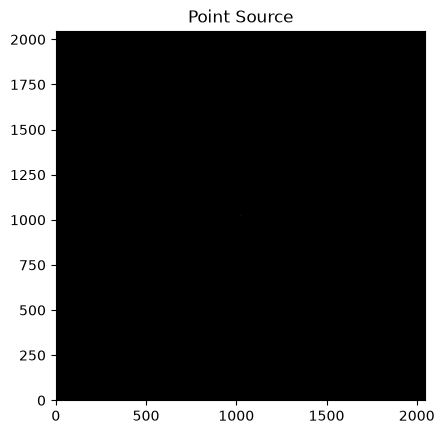

In [4]:
star_image = scene.displaySource(
    telescope=my_telescope,
    passband="g",
    source_index=0,
    exptime=100
)

plt.imshow(star_image, cmap = "gray", origin = "lower")
plt.title("Point Source")
plt.show()

## Galaxy Sources

Galaxy sources, like point sources are added with `addSource()`, but use a `GalaxySource` object. They also require magnitudes.

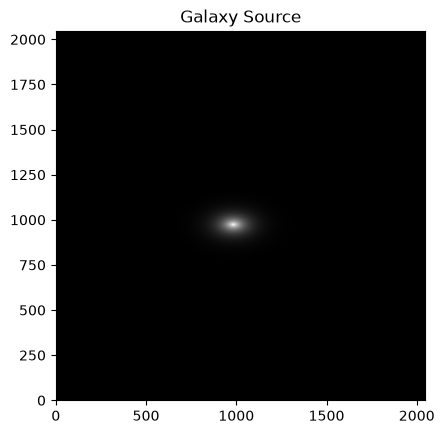

In [5]:
galaxy = GalaxySource(
    r_eff= 10, n=1, axial_ratio= 0.6)

scene.addSource(
    source=galaxy,
    mag=19,
    delta_x=-40,
    delta_y=-50
)

galaxy_image = scene.displaySource(
    telescope=my_telescope,
    passband="g",
    source_index=1,
    exptime=100
)

plt.imshow(galaxy_image, cmap = "gray", origin = "lower")
plt.title("Galaxy Source")
plt.show()

## Custom Sources

Custom sources allow user-defined source profiles.
If a magnitude is provided, the profile is normalized to that magnitude. If no magnitude is supplied, the source is displayed using the counts contained in the custom profile.

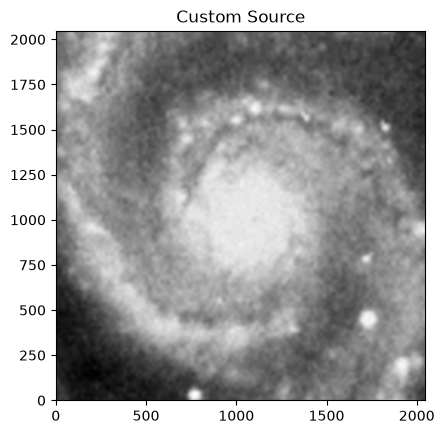

In [6]:
m51_source = CustomSource(
    profile_filepath="m51_dss.fits",
    passband="g",
    center=None,
    px_scale_unit=u.deg,
)

scene.addSource(
    source=m51_source,
    mag=None,
    delta_x=-10,
    delta_y=40
)

custom_image = scene.displaySource(
    telescope=my_telescope,
    passband="g",
    source_index=2,
    exptime=100
)

plt.imshow(custom_image, cmap = "gray", origin = "lower")
plt.title("Custom Source")
plt.show()

## Displaying the Complete Scene

The `displayScene()` method combines all sources in the scene into a single image.

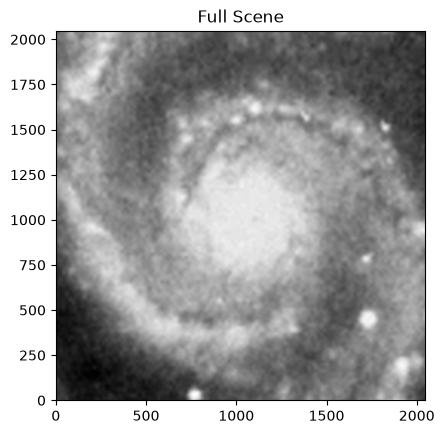

In [7]:
scene_image = scene.displayScene(
    telescope=my_telescope,
    passband="g",
    exptime=100
)

plt.imshow(scene_image, cmap = "gray", origin = "lower")
plt.title("Full Scene")
plt.show()